In [1]:
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from neural_network import normalize, train_neural_network, DATA_HEADERS
import pandas as pd
import numpy as np

C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
non_bag_url = "https://raw.githubusercontent.com/reganq/csc311-project/refs/heads/main/cleaned_data.csv"
non_bag_df = pd.read_csv(non_bag_url)
bag_url = "../cleaned_data_bag.csv"
bag_df = pd.read_csv(bag_url)

In [3]:
df = non_bag_df.copy()

In [4]:
# split the data
train_df = df[df['is_train'] == True]
val_df = df[df['is_train'] == False]

# split off the labels - they cannot be one-hot encoded for logreg. Instead, we have 3 targets (0, 1, 2)
t_train = np.argmax(np.stack([
    (train_df['painting'] == 'The Persistence of Memory').astype(np.int8),
    (train_df['painting'] == 'The Starry Night').astype(np.int8),
    (train_df['painting'] == 'The Water Lily Pond').astype(np.int8)
]), axis=0)

t_val = np.argmax(np.stack([
    (val_df['painting'] == 'The Persistence of Memory').astype(np.int8),
    (val_df['painting'] == 'The Starry Night').astype(np.int8),
    (val_df['painting'] == 'The Water Lily Pond').astype(np.int8)
]), axis=0)

# headers = DATA_HEADERS
headers = df.columns.values.tolist()
headers.remove('unique_id')
headers.remove('painting')
headers.remove('is_train')

X_train = np.array(train_df.get(headers))
X_train = X_train.astype(np.int8) # get rid of those pesky floats
X_val = np.array(val_df.get(headers))
X_val = X_val.astype(np.int8)

In [5]:
# normalize the (non-BOW) data
X_train[:20] = normalize(X_train[:20])
X_val[:20] = normalize(X_val[:20])

c:\Users\ecorb\OneDrive\Documents\school\2025-26\CSC311\csc311-project\neural_network\neural_network.py:81: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std
C:\Users\ecorb\AppData\Local\Temp\ipykernel_24468\1208814450.py:2: RuntimeWarning: invalid value encountered in cast
  X_train[:20] = normalize(X_train[:20])
C:\Users\ecorb\AppData\Local\Temp\ipykernel_24468\1208814450.py:3: RuntimeWarning: invalid value encountered in cast
  X_val[:20] = normalize(X_val[:20])


In [6]:
def build_all_models(alpha,
                     activation,
                     batch_size,
                     hidden_layer_sizes,
                     X_train=X_train,
                     t_train=t_train,
                     X_valid=X_val,
                     t_valid=t_val):
    """
    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    Arguments:
        - alpha: Regularization strength.
        - activation: Which activation function to use.
        - batch_size: Size of the mini-batches for stochastic optimizers.
        - hidden_layer_sizes: Tuple of integers. The i-th element represents the number of neurons in the i-th hidden layer.
    """
    out = {}

    for a in alpha:
        for act in activation:
            for b in batch_size:
                for h in hidden_layer_sizes:
                    out[(a, act, b, h)] = {}
                    # Create a neural network model based on the given hyperparameters and fit it to the data
                    model = train_neural_network(X_train, t_train, alpha=a, activation=act, batch_size=b, hidden_layer_sizes=h)
                    
                    # store the validation and training scores in the `out` dictionary
                    out[(a, act, b, h)]['val'] = model.score(X_valid, t_valid)
                    out[(a, act, b, h)]['train'] = model.score(X_train, t_train)
    return out

In [7]:
first_model = train_neural_network(X_train, t_train, alpha=0.0001, activation='relu', batch_size=32, hidden_layer_sizes=(100,))
print("First model training accuracy:", first_model.score(X_train, t_train))
print("First model validation accuracy:", first_model.score(X_val, t_val))

First model training accuracy: 0.9737827715355806
First model validation accuracy: 0.8242424242424242


C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Hyperparameters values
alpha = [0.00001, 0.0001, 0.001]
activation = ['relu', 'tanh']
batch_size = [16, 32, 48, 64]
hidden_layer_sizes = [(25,), (25, 25), (50,), (50, 50), (100,), (100, 100)]

res = build_all_models(alpha=alpha, activation=activation, batch_size=batch_size, hidden_layer_sizes=hidden_layer_sizes) # call `build_all_models` for the given hyperparameters

# search for the optimal combination of parameters given this criterion
max_score = 0
best_params = None
for a, act, b, h in res:
    if res[(a, act, b, h)]['val'] > max_score:
        max_score = res[(a, act, b, h)]['val']
        best_params = (a, act, b, h)

print(f"Best parameters: {best_params}")
print(f"Best score: {max_score}")

C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Best parameters: (0.0001, 'tanh', 32, (50,))
Best score: 0.8393939393939394


C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
res_df = pd.DataFrame.from_dict(res, orient='index')
res_df.index.names = ['alpha', 'activation', 'batch_size', 'hidden_layer_sizes']
res_df.to_csv("nn_tuning_results_non_bag.csv")

In [ ]:
# with bag of words
# Best parameters: (0.0001, 'relu', 32, (100,))
# Best score: 0.8643067846607669
# without bag of words
# Best parameters: (0.0001, 'tanh', 32, (50,))
# Best score: 0.8393939393939394

In [11]:
best_model_bag = train_neural_network(X_train, t_train, alpha=0.0001, activation='relu', batch_size=32, hidden_layer_sizes=(100,))
best_model_non_bag = train_neural_network(X_train, t_train, alpha=0.0001, activation='tanh', batch_size=32, hidden_layer_sizes=(50,))

C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ecorb\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
print(metrics.classification_report(t_val, best_model_bag.predict(X_val)))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       110
           1       0.77      0.75      0.76       110
           2       0.86      0.82      0.84       110

    accuracy                           0.82       330
   macro avg       0.82      0.82      0.82       330
weighted avg       0.82      0.82      0.82       330



In [20]:
print(metrics.classification_report(t_val, best_model_non_bag.predict(X_val)))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       110
           1       0.79      0.76      0.78       110
           2       0.85      0.85      0.85       110

    accuracy                           0.84       330
   macro avg       0.84      0.84      0.84       330
weighted avg       0.84      0.84      0.84       330



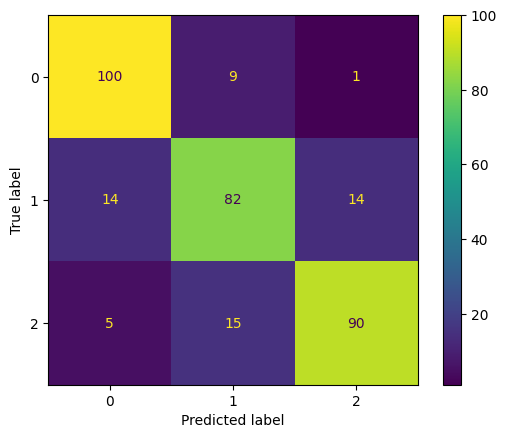

In [14]:
ConfusionMatrixDisplay.from_predictions(t_val, best_model_bag.predict(X_val))

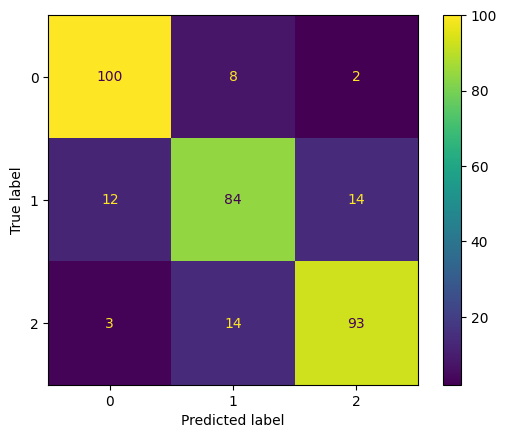

In [21]:
ConfusionMatrixDisplay.from_predictions(t_val, best_model_non_bag.predict(X_val))